# 4 Předzpracování dat

Tento notebook popisuje praktickou přípravu dat pro experimentální klasifikaci dětského pláče.

Cílem notebooku je:

- načíst metadata a zvukové soubory,
- ověřit základní technické vlastnosti audiosouborů,
- sjednotit délku audiosignálů,
- rozdělit data na trénovací a testovací část,
- aplikovat akustickou augmentaci pouze na trénovací data,
- připravit tři hierarchické sady akustických příznaků,
- vytvořit datové sady pro jednotlivé experimentální scénáře,
- uložit předzpracované datasety pro navazující modelovací část.

Výstupy z notebooku slouží jako podklad pro experimentální ověření klasifikačních modelů v další části práce.

In [1]:
import os
import wave
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import time

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

BASE_PATH = os.path.join("..", "dataset")
OUTPUT_DIR = os.path.join("..", "outputs")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
PREPROCESSED_DIR = os.path.join(OUTPUT_DIR, "preprocessed")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

## 4.1 Přehled experimentální přípravy dat

Vzhledem k výrazné třídní nevyváženosti datasetu jsou v práci porovnávány tři základní strategie:

1. **Algorithm-level přístup** – původní data bez augmentace, nerovnováha je řešena pomocí vážení tříd.
2. **Data-level přístup** – minoritní třídy jsou částečně navýšeny pomocí akustické augmentace.
3. **Hybridní přístup** – kombinace augmentace minoritních tříd a vážení chybové funkce modelů.

Tyto strategie jsou v navazující modelovací části kombinovány se třemi klasifikačními algoritmy a třemi sadami příznaků. V tomto notebooku jsou pro uvedené strategie připraveny odpovídající trénovací a testovací datové sady.

In [2]:
POHLAVI_MAP = {
    "m": "chlapec",
    "f": "dívka"
}

VEK_MAP = {
    "04": "0–4 týdny",
    "48": "4–8 týdnů",
    "26": "2–6 měsíců",
    "72": "7 měsíců–2 roky",
    "22": "více než 2 roky"
}

TRIDA_MAP_CZ = {
    "hungry": "hlad",
    "discomfort": "nepohodlí",
    "tired": "únava",
    "belly_pain": "bolest břicha",
    "belly pain": "bolest břicha",
    "burping": "říhání"
}

PORADI_TRID = ["hlad", "nepohodlí", "únava", "bolest břicha", "říhání"]

TARGET_SR = 8000
TARGET_DURATION = 7.0
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

N_MFCC = 13
WIN_LENGTH = 256
N_FFT = 512
HOP_LENGTH = 80

RANDOM_STATE = 42
TEST_SIZE = 0.2

FEATURE_SETS = ["basic", "extended", "advanced"]
BALANCING_STRATEGIES = ["algorithm_level", "data_level", "hybrid"]

## 4.2 Načtení metadat a kontrola technických vlastností audiosouborů

Prvním krokem je načtení metadat z názvů souborů a ověření základních technických parametrů audiosouborů. Kontrolována je zejména vzorkovací frekvence, bitová hloubka, počet kanálů a délka signálu.

In [3]:
def parse_metadata_from_filename(filename):

    name, ext = os.path.splitext(filename)
    parts = name.split("-")

    if len(parts) < 5:
        return None

    reason = parts[-1].lower()
    age_code = parts[-2]
    gender_code = parts[-3].lower()
    app_version = parts[-4]
    timestamp = parts[-5]

    return {
        "soubor": filename,
        "format": ext.lower(),
        "casove_razitko": timestamp,
        "verze_aplikace": app_version,
        "kod_pohlavi": gender_code,
        "pohlavi": POHLAVI_MAP.get(gender_code, "neznámé"),
        "kod_veku": age_code,
        "vekova_kategorie": VEK_MAP.get(age_code, "neznámé"),
        "kod_tridy": reason
    }


def get_wav_properties(file_path):

    with wave.open(file_path, "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        sample_width_bytes = wav_file.getsampwidth()
        channels = wav_file.getnchannels()
        n_frames = wav_file.getnframes()
        duration_sec = n_frames / sample_rate if sample_rate else 0

    return {
        "vzorkovaci_frekvence_hz": sample_rate,
        "bitova_hloubka": sample_width_bytes * 8,
        "pocet_kanalu": channels,
        "pocet_vzorku": n_frames,
        "delka_s": round(duration_sec, 3)
    }

In [4]:
records = []

for class_name in os.listdir(BASE_PATH):
    class_path = os.path.join(BASE_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if not file.lower().endswith(".wav"):
            continue

        file_path = os.path.join(class_path, file)
        metadata = parse_metadata_from_filename(file)

        if metadata is None:
            continue

        wav_props = get_wav_properties(file_path)

        row = {
            "trida": class_name,
            "trida_cz": TRIDA_MAP_CZ.get(class_name, class_name),
            "cesta": file_path
        }

        row.update(metadata)
        row.update(wav_props)
        records.append(row)

df_meta = pd.DataFrame(records)

print(f"Celkový počet načtených nahrávek: {len(df_meta)}")
df_meta.head()

Celkový počet načtených nahrávek: 457


,trida,trida_cz,cesta,soubor,format,casove_razitko,verze_aplikace,kod_pohlavi,pohlavi,kod_veku,vekova_kategorie,kod_tridy,vzorkovaci_frekvence_hz,bitova_hloubka,pocet_kanalu,pocet_vzorku,delka_s
0,belly_pain,bolest břicha,..\dataset\belly_pain\549a46d8-9c84-430e-ade8-...,549a46d8-9c84-430e-ade8-97eae2bef787-143013077...,.wav,1430130772174,1.7,m,chlapec,48,4–8 týdnů,bp,8000,16,1,54880,6.86
1,belly_pain,bolest břicha,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013849...,.wav,1430138495,1.0,m,chlapec,72,7 měsíců–2 roky,bp,8000,16,1,56000,7.00
2,belly_pain,bolest břicha,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013850...,.wav,1430138506,1.0,m,chlapec,72,7 měsíců–2 roky,bp,8000,16,1,56000,7.00
3,belly_pain,bolest břicha,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013851...,.wav,1430138514,1.0,m,chlapec,72,7 měsíců–2 roky,bp,8000,16,1,56000,7.00
4,belly_pain,bolest břicha,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013852...,.wav,1430138524,1.0,m,chlapec,72,7 měsíců–2 roky,bp,8000,16,1,56000,7.00


In [5]:
technicka_kontrola = pd.DataFrame({
    "Parametr": [
        "Formát souboru",
        "Vzorkovací frekvence",
        "Bitová hloubka",
        "Počet kanálů"
    ],
    "Unikátní hodnoty": [
        ", ".join(map(str, sorted(df_meta["format"].dropna().unique()))),
        ", ".join(map(str, sorted(df_meta["vzorkovaci_frekvence_hz"].dropna().unique()))),
        ", ".join(map(str, sorted(df_meta["bitova_hloubka"].dropna().unique()))),
        ", ".join(map(str, sorted(df_meta["pocet_kanalu"].dropna().unique())))
    ],
    "Počet unikátních hodnot": [
        df_meta["format"].nunique(),
        df_meta["vzorkovaci_frekvence_hz"].nunique(),
        df_meta["bitova_hloubka"].nunique(),
        df_meta["pocet_kanalu"].nunique()
    ]
})

technicka_kontrola

,Parametr,Unikátní hodnoty,Počet unikátních hodnot
0,Formát souboru,.wav,1
1,Vzorkovací frekvence,8000,1
2,Bitová hloubka,16,1
3,Počet kanálů,1,1


## 4.3 Analýza a sjednocení délky signálu

Pro následnou extrakci příznaků je vhodné sjednotit délku všech zvukových záznamů. Cílová délka byla stanovena na 7 sekund, protože rozložení délek nahrávek ukazuje, že se většina záznamů této hodnotě přirozeně blíží.

Kratší signály jsou doplněny nulami na konci signálu (*zero-padding*), zatímco delší signály jsou oříznuty (*trimming*).

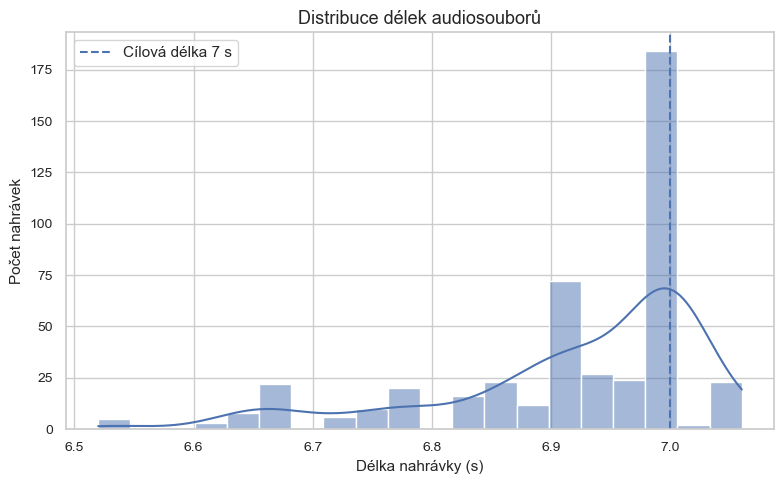

In [6]:
plt.figure(figsize=(8, 5))

ax = sns.histplot(
    data=df_meta,
    x="delka_s",
    bins=20,
    kde=True
)

ax.set_title("Distribuce délek audiosouborů")
ax.set_xlabel("Délka nahrávky (s)")
ax.set_ylabel("Počet nahrávek")

plt.axvline(TARGET_DURATION, linestyle="--", label=f"Cílová délka {TARGET_DURATION:g} s")
plt.legend()
plt.tight_layout()

output_path = os.path.join(FIGURES_DIR, "distribuce_delek_audio.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

In [7]:
def load_and_fix_length(file_path, sr=TARGET_SR, target_length=TARGET_LENGTH):

    signal, sample_rate = librosa.load(file_path, sr=sr, mono=True)

    original_length = len(signal)

    if original_length < target_length:
        signal = np.pad(signal, (0, target_length - original_length), mode="constant")
        operation = "zero-padding"
    elif original_length > target_length:
        signal = signal[:target_length]
        operation = "trimming"
    else:
        operation = "beze změny"

    return signal, sample_rate, operation

In [8]:
operations = []

for _, row in df_meta.iterrows():
    signal, sample_rate, operation = load_and_fix_length(row["cesta"])

    operations.append({
        "soubor": row["soubor"],
        "trida": row["trida"],
        "trida_cz": row["trida_cz"],
        "puvodni_delka_s": row["delka_s"],
        "nova_delka_s": round(len(signal) / sample_rate, 3),
        "operace": operation
    })

df_length_check = pd.DataFrame(operations)

length_summary = df_length_check["operace"].value_counts().rename_axis("Operace").reset_index(name="Počet nahrávek")
length_summary

,Operace,Počet nahrávek
0,zero-padding,250
1,beze změny,182
2,trimming,25


## 4.4 Stratifikované rozdělení dat

Dataset je rozdělen na trénovací a testovací část v poměru 80 : 20. Vzhledem k výrazné třídní nevyváženosti je použito stratifikované rozdělení, aby byly ve výsledných množinách zachovány poměry jednotlivých tříd.

Testovací množina je ponechána stranou a není použita při augmentaci. Standardizace příznaků je provedena až v navazujícím modelovacím notebooku, kde jsou její parametry odvozovány pouze z trénovací části dat.

In [9]:
train_meta, test_meta = train_test_split(
    df_meta,
    test_size=TEST_SIZE,
    stratify=df_meta["trida"],
    random_state=RANDOM_STATE
)

train_meta = train_meta.reset_index(drop=True)
test_meta = test_meta.reset_index(drop=True)

print(f"Počet trénovacích nahrávek: {len(train_meta)}")
print(f"Počet testovacích nahrávek: {len(test_meta)}")

Počet trénovacích nahrávek: 365
Počet testovacích nahrávek: 92


In [10]:
split_summary = pd.DataFrame({
    "Celkem": df_meta["trida_cz"].value_counts(),
    "Train": train_meta["trida_cz"].value_counts(),
    "Test": test_meta["trida_cz"].value_counts()
}).reindex(PORADI_TRID)

split_summary["Celkem (%)"] = (split_summary["Celkem"] / split_summary["Celkem"].sum() * 100).round(2)
split_summary["Train (%)"] = (split_summary["Train"] / split_summary["Train"].sum() * 100).round(2)
split_summary["Test (%)"] = (split_summary["Test"] / split_summary["Test"].sum() * 100).round(2)

split_summary = split_summary[
    ["Celkem", "Celkem (%)", "Train", "Train (%)", "Test", "Test (%)"]
]

split_summary

,Celkem,Celkem (%),Train,Train (%),Test,Test (%)
trida_cz,,,,,,
hlad,382,83.59,305,83.56,77,83.70
nepohodlí,27,5.91,22,6.03,5,5.43
únava,24,5.25,19,5.21,5,5.43
bolest břicha,16,3.50,13,3.56,3,3.26
říhání,8,1.75,6,1.64,2,2.17


## 4.5 Akustická augmentace trénovacích dat

V rámci data-level a hybridního scénáře je použita akustická augmentace pomocí přidání Gaussovského šumu. Tato technika slouží k částečnému navýšení počtu trénovacích instancí v minoritních třídách.

Augmentace je aplikována výhradně na trénovací množinu, aby nedošlo k úniku informací do testovacích dat.

In [11]:
def add_gaussian_noise(signal, noise_min=0.01, noise_max=0.015, random_state=None):
    """
    Přidá k signálu Gaussovský šum s náhodně zvolenou amplitudou
    v zadaném intervalu.
    """
    rng = np.random.default_rng(random_state)
    noise_factor = rng.uniform(noise_min, noise_max)
    noise = rng.normal(0, 1, len(signal))

    augmented_signal = signal + noise_factor * noise

    return augmented_signal.astype(np.float32)

In [12]:
def create_augmented_training_metadata(train_df, augmentation_factor=3, majority_class=None):
    """
    Vytvoří metadata pro augmentovanou trénovací množinu.

    Majoritní třída zůstává bez augmentace.
    Minoritní třídy jsou navýšeny podle zvoleného faktoru.
    Faktor 3 znamená: původní vzorek + 2 augmentované varianty.
    """
    if majority_class is None:
        majority_class = train_df["trida"].value_counts().idxmax()

    augmented_records = []

    for _, row in train_df.iterrows():
        base_record = row.to_dict()
        base_record["is_augmented"] = False
        base_record["augmentation_id"] = 0
        augmented_records.append(base_record)

        if row["trida"] != majority_class:
            for aug_id in range(1, augmentation_factor):
                aug_record = row.to_dict()
                aug_record["is_augmented"] = True
                aug_record["augmentation_id"] = aug_id
                augmented_records.append(aug_record)

    return pd.DataFrame(augmented_records)

In [13]:
train_meta_aug = create_augmented_training_metadata(train_meta, augmentation_factor=3)

augment_summary = pd.DataFrame({
    "Train před augmentací": train_meta["trida_cz"].value_counts(),
    "Train po augmentaci": train_meta_aug["trida_cz"].value_counts()
}).reindex(PORADI_TRID)

augment_summary

,Train před augmentací,Train po augmentaci
trida_cz,,
hlad,305,305
nepohodlí,22,66
únava,19,57
bolest břicha,13,39
říhání,6,18


Přídavek Gaussovského šumu je nutné chápat jako zjednodušený model variability reálného prostředí. Na rozdíl od skutečných podmínek nezachycuje komplexní změny v intonaci, hlasitosti nebo emočním projevu dítěte.

Z tohoto důvodu je augmentace použita pouze v omezeném rozsahu. Cílem není vytvořit plně vyvážený dataset, ale mírně rozšířit příznakový prostor minoritních tříd bez nadměrného rizika přeučení na několik málo původních nahrávek.

## 4.6 Extrakce akustických příznaků

Pro klasifikaci jsou připraveny tři hierarchické sady příznaků:

1. **Basic** – 13 MFCC koeficientů.
2. **Extended** – MFCC + základní spektrální a energetické charakteristiky.
3. **Advanced** – Extended + delta MFCC a Chroma STFT.

U každého příznaku je vypočtena průměrná hodnota a směrodatná odchylka napříč časovými rámci, čímž je každá nahrávka převedena na pevně dlouhý vektor numerických příznaků.

In [14]:
def summarize_feature_matrix(feature_matrix, prefix):
    """
    Z matice příznaků vytvoří agregované statistiky:
    průměr a směrodatnou odchylku pro každý řádek matice.
    """
    features = {}

    for i in range(feature_matrix.shape[0]):
        values = feature_matrix[i]
        features[f"{prefix}_{i+1}_mean"] = float(np.mean(values))
        features[f"{prefix}_{i+1}_std"] = float(np.std(values))

    return features

In [15]:
def extract_basic_features(signal, sr=TARGET_SR):
    """
    Basic sada:
    - 13 MFCC koeficientů
    - průměr a směrodatná odchylka
    """
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann"
    )

    features = summarize_feature_matrix(mfcc, "mfcc")

    return features

In [16]:
def extract_extended_features(signal, sr=TARGET_SR):
    """
    Extended sada:
    - Basic sada
    - Zero Crossing Rate
    - RMS energie
    - Spektrální centroid
    - Spektrální bandwidth
    - Spektrální rolloff
    - Spektrální flatness
    """
    features = extract_basic_features(signal, sr)

    zcr = librosa.feature.zero_crossing_rate(
        y=signal,
        frame_length=WIN_LENGTH,
        hop_length=HOP_LENGTH
    )
    
    rms = librosa.feature.rms(
        y=signal,
        frame_length=WIN_LENGTH,
        hop_length=HOP_LENGTH
    )
    
    centroid = librosa.feature.spectral_centroid(
        y=signal,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann"
    )
    
    bandwidth = librosa.feature.spectral_bandwidth(
        y=signal,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann"
    )
    
    rolloff = librosa.feature.spectral_rolloff(
        y=signal,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann"
    )
    
    flatness = librosa.feature.spectral_flatness(
        y=signal,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann"
    )

    extra_features = {
        "zcr": zcr,
        "rms": rms,
        "centroid": centroid,
        "bandwidth": bandwidth,
        "rolloff": rolloff,
        "flatness": flatness
    }

    for name, matrix in extra_features.items():
        features[f"{name}_mean"] = float(np.mean(matrix))
        features[f"{name}_std"] = float(np.std(matrix))

    return features

In [17]:
def extract_advanced_features(signal, sr=TARGET_SR):
    """
    Advanced sada:
    - Extended sada
    - Delta MFCC
    - Chroma STFT
    """
    features = extract_extended_features(signal, sr)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann"
    )

    delta_mfcc = librosa.feature.delta(mfcc)
    chroma = librosa.feature.chroma_stft(
        y=signal,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann"
    )

    features.update(summarize_feature_matrix(delta_mfcc, "delta_mfcc"))
    features.update(summarize_feature_matrix(chroma, "chroma"))

    return features

In [18]:
def extract_feature_set(signal, sr=TARGET_SR, feature_set="basic"):
    """
    Vybere požadovanou sadu příznaků.
    """
    if feature_set == "basic":
        return extract_basic_features(signal, sr)

    if feature_set == "extended":
        return extract_extended_features(signal, sr)

    if feature_set == "advanced":
        return extract_advanced_features(signal, sr)

    raise ValueError(f"Neznámá sada příznaků: {feature_set}")

In [19]:
feature_extraction_times = []

sample_rows = df_meta.sample(
    n=min(50, len(df_meta)),
    random_state=RANDOM_STATE
)

for feature_set in FEATURE_SETS:
    times = []
    
    for _, row in sample_rows.iterrows():
        signal, sr, _ = load_and_fix_length(row["cesta"])
        
        start_time = time.perf_counter()
        _ = extract_feature_set(signal, sr=sr, feature_set=feature_set)
        elapsed_time = time.perf_counter() - start_time
        
        times.append(elapsed_time)
    
    feature_extraction_times.append({
        "feature_set": feature_set,
        "n_samples": len(sample_rows),
        "mean_time_ms": np.mean(times) * 1000,
        "median_time_ms": np.median(times) * 1000,
        "std_time_ms": np.std(times) * 1000
    })

feature_extraction_time_df = pd.DataFrame(feature_extraction_times)
feature_extraction_time_df.round(2)

,feature_set,n_samples,mean_time_ms,median_time_ms,std_time_ms
0,basic,50,9.44,6.97,16.42
1,extended,50,36.64,36.25,2.48
2,advanced,50,54.23,53.65,4.43


In [20]:
feature_time_path = os.path.join(
    PREPROCESSED_DIR,
    "feature_extraction_times.csv"
)

feature_extraction_time_df.to_csv(
    feature_time_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Časy extrakce příznaků byly uloženy do: {feature_time_path}")

Časy extrakce příznaků byly uloženy do: ..\outputs\preprocessed\feature_extraction_times.csv


Použitá agregace umožňuje převést audiosignály různé povahy na jednotný tabulkový formát vhodný pro klasické algoritmy strojového učení. Zároveň však nezachovává úplný časový průběh zvukového signálu.

## 4.7 Příprava datasetů pro jednotlivé experimentální scénáře

V této části jsou připraveny datové tabulky pro jednotlivé kombinace:

- příznaková sada: Basic, Extended, Advanced,
- strategie vyvážení: Algorithm-level, Data-level, Hybrid.

Rozdíl mezi scénáři spočívá především v tom, zda je použita augmentovaná trénovací množina a zda se v modelu později použije vážení tříd. Testovací množina zůstává ve všech scénářích stejná a není augmentována.

In [21]:
def build_features_dataframe(meta_df, feature_set, apply_augmentation=False):
    """
    Vytvoří tabulku příznaků pro zadanou metadatovou tabulku.

    Pokud je apply_augmentation=True, jsou řádky označené jako augmentované
    zpracovány přidáním bílého šumu.
    """
    records = []
    errors = []

    for row_idx, (_, row) in enumerate(meta_df.iterrows()):
        try:
            signal, sr, _ = load_and_fix_length(row["cesta"])

            if apply_augmentation and row.get("is_augmented", False):
                signal = add_gaussian_noise(
                    signal,
                    noise_min=0.01,
                    noise_max=0.015,
                    random_state=RANDOM_STATE + int(row.get("augmentation_id", 0)) * 100000 + row_idx
                )

            features = extract_feature_set(signal, sr=sr, feature_set=feature_set)

            result = {
                "soubor": row["soubor"],
                "cesta": row["cesta"],
                "trida": row["trida"],
                "trida_cz": row["trida_cz"],
                "pohlavi": row["pohlavi"],
                "vekova_kategorie": row["vekova_kategorie"],
                "is_augmented": row.get("is_augmented", False),
                "augmentation_id": row.get("augmentation_id", 0)
            }

            result.update(features)
            records.append(result)

        except Exception as e:
            errors.append((row["soubor"], str(e)))

    df = pd.DataFrame(records)

    return df, errors

In [22]:
all_datasets = {}

for feature_set in FEATURE_SETS:
    print(f"Zpracovávám příznakovou sadu: {feature_set}")

    # Algorithm-level scénář: původní train bez augmentace
    train_alg, errors_train_alg = build_features_dataframe(
        train_meta,
        feature_set=feature_set,
        apply_augmentation=False
    )

    # Data-level / Hybrid scénář: augmentovaný train
    train_aug, errors_train_aug = build_features_dataframe(
        train_meta_aug,
        feature_set=feature_set,
        apply_augmentation=True
    )

    # Testovací sada je vždy stejná a nikdy se neaugmentuje
    test_df, errors_test = build_features_dataframe(
        test_meta,
        feature_set=feature_set,
        apply_augmentation=False
    )

    all_datasets[(feature_set, "algorithm_level")] = {
        "train": train_alg,
        "test": test_df
    }

    all_datasets[(feature_set, "data_level")] = {
        "train": train_aug,
        "test": test_df
    }

    all_datasets[(feature_set, "hybrid")] = {
        "train": train_aug,
        "test": test_df
    }

    print(f"  Train bez augmentace: {len(train_alg)}")
    print(f"  Train s augmentací: {len(train_aug)}")
    print(f"  Test: {len(test_df)}")
    print(f"  Chyby: {len(errors_train_alg) + len(errors_train_aug) + len(errors_test)}")

Zpracovávám příznakovou sadu: basic
  Train bez augmentace: 365
  Train s augmentací: 485
  Test: 92
  Chyby: 0
Zpracovávám příznakovou sadu: extended
  Train bez augmentace: 365
  Train s augmentací: 485
  Test: 92
  Chyby: 0
Zpracovávám příznakovou sadu: advanced
  Train bez augmentace: 365
  Train s augmentací: 485
  Test: 92
  Chyby: 0


V Advanced sadě je z důvodu jednodušší struktury funkcí MFCC matice vypočtena opakovaně. Vzhledem k velikosti datasetu nemá tato redundance významný dopad na výpočetní náročnost.

## 4.8 Uložení předzpracovaných dat

Připravené datové sady jsou uloženy do výstupní složky ve formátu CSV. Každá kombinace příznakové sady a strategie vyvážení obsahuje samostatný trénovací a testovací soubor.

Výstupní soubory obsahují extrahované akustické příznaky a související metadata. Finální standardizace příznaků je provedena až v navazujícím modelovacím notebooku pomocí trénovací pipeline, aby nedocházelo k úniku informací při trénování a vyhodnocování modelů.

Data-level a hybridní scénář využívají stejnou augmentovanou trénovací množinu. Rozdíl mezi nimi vzniká až v modelovací fázi, kde hybridní scénář kombinuje augmentaci s vážením tříd.

In [23]:
for key, dataset in all_datasets.items():
    feature_set, strategy = key

    train_df = dataset["train"].copy()
    test_df = dataset["test"].copy()

    train_path = os.path.join(PREPROCESSED_DIR, f"train_{feature_set}_{strategy}.csv")
    test_path = os.path.join(PREPROCESSED_DIR, f"test_{feature_set}_{strategy}.csv")

    train_df.to_csv(train_path, index=False, encoding="utf-8-sig")
    test_df.to_csv(test_path, index=False, encoding="utf-8-sig")

    print(f"Uloženo: {train_path}")
    print(f"Uloženo: {test_path}")

Uloženo: ..\outputs\preprocessed\train_basic_algorithm_level.csv
Uloženo: ..\outputs\preprocessed\test_basic_algorithm_level.csv
Uloženo: ..\outputs\preprocessed\train_basic_data_level.csv
Uloženo: ..\outputs\preprocessed\test_basic_data_level.csv
Uloženo: ..\outputs\preprocessed\train_basic_hybrid.csv
Uloženo: ..\outputs\preprocessed\test_basic_hybrid.csv
Uloženo: ..\outputs\preprocessed\train_extended_algorithm_level.csv
Uloženo: ..\outputs\preprocessed\test_extended_algorithm_level.csv
Uloženo: ..\outputs\preprocessed\train_extended_data_level.csv
Uloženo: ..\outputs\preprocessed\test_extended_data_level.csv
Uloženo: ..\outputs\preprocessed\train_extended_hybrid.csv
Uloženo: ..\outputs\preprocessed\test_extended_hybrid.csv
Uloženo: ..\outputs\preprocessed\train_advanced_algorithm_level.csv
Uloženo: ..\outputs\preprocessed\test_advanced_algorithm_level.csv
Uloženo: ..\outputs\preprocessed\train_advanced_data_level.csv
Uloženo: ..\outputs\preprocessed\test_advanced_data_level.csv
Ulož

## 4.9 Shrnutí předzpracování dat

V tomto notebooku byla připravena datová pipeline pro experimentální klasifikaci dětského pláče. Nejprve byla načtena metadata a ověřeny základní technické parametry audiosouborů. Následně byla sjednocena délka zvukových signálů na 7 sekund pomocí zero-paddingu a ořezu.

Dataset byl rozdělen na trénovací a testovací část stratifikovaným způsobem v poměru 80:20. Akustická augmentace pomocí přidání bílého šumu byla aplikována výhradně na trénovací data, aby nedošlo k úniku informací do testovací množiny.

Pro potřeby navazujících experimentů byly připraveny tři hierarchické sady akustických příznaků: Basic, Extended a Advanced. Pro každou kombinaci příznakové sady a strategie vyvážení byly vytvořeny samostatné trénovací a testovací tabulky.

Výstupy notebooku jsou uloženy ve složce outputs/preprocessed a slouží jako vstup pro navazující notebook zaměřený na trénování a vyhodnocení klasifikačních modelů. Finální standardizace příznaků je provedena až v modelovací části pomocí pipeline jednotlivých modelů.